# 07 - Physics-Informed Neural Network for Temperature Forecasting

## Objective

In the previous notebook, physics-inspired features and ΔΤ prediction significantly improved forecasting performance.

Here we take a further step by incorporating physical constraints directly into the training process.

The objective is to evaluate whether a Physics-Informed Neural Network (PINN) can learn physically meaningfull thermal dynamics and maintain accurate temperature forecasts?

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv("../data/processed/TempHumData_27_4_26.csv", parse_dates=["time"])

df = df.set_index("time").sort_index()

cutoff = "2026-02-22 17:00:00"
df = df[df.index >= cutoff].copy()

# print(df.shape)
# df.head()

### Time Features

In [3]:
def add_time_features(df):
    df = df.copy()

    hour = df.index.hour
    doy = df.index.dayofyear

    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    df["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 365)

    return df

### PINN dataset Representation

In [4]:
pinn_df = df.copy()
pinn_df = add_time_features(pinn_df)

pinn_df["temp_out_mean_c"] = (
    pinn_df["temp_out_1_b_c"] + pinn_df["temp_out_2_n_c"]
) / 2

pinn_df["solar_proxy"] = (
    pinn_df["temp_out_2_n_c"] - pinn_df["temp_out_1_b_c"]
)

# discrete hourly temperature derivatives
pinn_df["dTdt_salon"] = pinn_df["temp_salon_c"].shift(-1) - pinn_df["temp_salon_c"]
pinn_df["dTdt_kids"] = pinn_df["temp_kids_c"].shift(-1) - pinn_df["temp_kids_c"]

# thermal drivers
pinn_df["driver_salon"] = pinn_df["temp_out_mean_c"] - pinn_df["temp_salon_c"]
pinn_df["driver_kids"] = pinn_df["temp_out_mean_c"] - pinn_df["temp_kids_c"]

pinn_df = pinn_df.dropna().copy()
pinn_df.head()


,temp_salon_c,temp_kids_c,hum_salon,hum_kids,temp_out_1_b_c,hum_out_1_b,temp_out_2_n_c,hum_out_2_n,hour_sin,hour_cos,doy_sin,doy_cos,temp_out_mean_c,solar_proxy,dTdt_salon,dTdt_kids,driver_salon,driver_kids
time,,,,,,,,,,,,,,,,,,
2026-02-22 17:00:00,18.45,19.84,63.91,55.66,9.89,66.82,17.01,55.45,-0.965926,-2.588190e-01,0.790946,0.611886,13.450,7.12,0.88,0.20,-5.000,-6.390
2026-02-22 18:00:00,19.33,20.04,63.81,56.66,9.23,70.83,11.63,63.32,-1.000000,-1.836970e-16,0.790946,0.611886,10.430,2.40,-0.26,-0.39,-8.900,-9.610
2026-02-22 19:00:00,19.07,19.65,65.78,60.08,8.89,70.79,10.33,66.01,-0.965926,2.588190e-01,0.790946,0.611886,9.610,1.44,0.37,0.19,-9.460,-10.040
2026-02-22 20:00:00,19.44,19.84,66.32,61.13,8.64,71.44,9.66,68.00,-0.866025,5.000000e-01,0.790946,0.611886,9.150,1.02,-0.18,-0.30,-10.290,-10.690
2026-02-22 21:00:00,19.26,19.54,65.34,61.40,8.44,75.14,9.39,71.99,-0.707107,7.071068e-01,0.790946,0.611886,8.915,0.95,-0.25,-0.24,-10.345,-10.625


### Define Inputs and Targets

In [5]:
pinn_features = [
    "temp_salon_c",
    "temp_kids_c",
    "temp_out_mean_c",
    "solar_proxy",
    "driver_salon",
    "driver_kids",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

pinn_targets = [
    "dTdt_salon",
    "dTdt_kids",
]

## 3. Train/Test split

In [6]:
split_idx = int(len(pinn_df) * 0.8)

train_df = pinn_df.iloc[:split_idx].copy()
test_df = pinn_df.iloc[split_idx:].copy()

X_train_raw = train_df[pinn_features].values
X_test_raw = test_df[pinn_features].values

y_train_raw = train_df[pinn_targets].values
y_test_raw = test_df[pinn_targets].values

print(X_train_raw.shape, y_train_raw.shape)
print(X_test_raw.shape, y_test_raw.shape)

(1214, 10) (1214, 2)
(304, 10) (304, 2)


## 4. Scaling

In [7]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train_raw)
X_test = x_scaler.fit_transform(X_test_raw)

y_train = y_scaler.fit_transform(y_train_raw)
y_test = y_scaler.fit_transform(y_test_raw)


## 5. PINN Formulation

Instead of relying only on data, the neural network is trained using both:

- data loss
- physics loss


The physics loss enforces consistency with a simplified thermal balance:

dT/dt = a · (Tout - Tin) + b · solar_proxy

where the coefficients a and b are learned during training.

In the previous notebook, physics-inspired features and ΔT prediction significantly improved forecasting performance.

Here we take a further step by incorporating physical knowledge directly into the training process.

Instead of minimizing only prediction error, the network is trained using a combination of:

- Data loss
- Physics loss

The physics loss penalizes violations of a simplified thermal balance equation, encouraging physically consistent predictions.

### Simple Neural Model

In [8]:
def build_pinn_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    x = layers.Dense(32, activation="tanh")(inputs)
    x = layers.Dense(32, activation="tanh")(x)
    x = layers.Dense(16, activation="tanh")(x)

    outputs = layers.Dense(2)(x)

    return Model(inputs, outputs)

pinn_model = build_pinn_model(len(pinn_features))
pinn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              34 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,970 (7.70 KB)

 Trainable params: 1,970 (7.70 KB)

 Non-trainable params: 0 (0.00 B)

### Prepare Physics tensors

In [9]:
# Convert train/test arrays to TensorFlow tensors

X_train_tf = tf.constant(X_train, dtype=tf.float32)
y_train_tf = tf.constant(y_train, dtype=tf.float32)

X_test_tf = tf.constant(X_test, dtype=tf.float32)
y_test_tf = tf.constant(y_test, dtype=tf.float32)

### Helper: inverse-transform predictions

The model predicts scaled dT/dt. For physics residual unscaled °C/hour is required.

In [10]:
y_mean = tf.constant(y_scaler.mean_, dtype=tf.float32)
y_scale = tf.constant(y_scaler.scale_, dtype=tf.float32)

def inverse_scale_y(y_scaled):
    return y_scaled * y_scale + y_mean

### Physics variables from unscaled X

In [11]:
x_mean = tf.constant(x_scaler.mean_, dtype=tf.float32)
x_scale = tf.constant(x_scaler.scale_, dtype=tf.float32)

feature_index = {name: i for i, name in enumerate(pinn_features)}

def inverse_scale_x(x_scaled):
    return x_scaled * x_scale + x_mean

def get_physics_variables(X_scaled):
    X_unscaled = inverse_scale_x(X_scaled)

    temp_salon = X_unscaled[:, feature_index["temp_salon_c"]]
    temp_kids = X_unscaled[:, feature_index["temp_kids_c"]]
    temp_out = X_unscaled[:, feature_index["temp_out_mean_c"]]
    solar = X_unscaled[:, feature_index["solar_proxy"]]

    driver_salon = temp_out - temp_salon
    driver_kids = temp_out - temp_kids

    return driver_salon, driver_kids, solar

### Trainable physics coefficients

Let model learn the coefficients:

dTdt = a * driver + b * solar

In [12]:
a_salon = tf.Variable(0.01, dtype=tf.float32, trainable=True, name="a_salon")
b_salon = tf.Variable(0.01, dtype=tf.float32, trainable=True, name="b_salon")

a_kids = tf.Variable(0.01, dtype=tf.float32, trainable=True, name="a_kids")
b_kids = tf.Variable(0.01, dtype=tf.float32, trainable=True, name="b_kids")

## 6. Loss function

The total loss combines two components:

L_total = L_data + λ · L_physics

where:

- L_data measures prediction accuracy from data.
- L_physics measures consistency with the thermal balance equation.
- λ controls the strength of the physical constraint.

This formulation allows the model to learn from data while remaining guided by known thermal behavior.

In [13]:
lambda_phys = 0.1

def compute_losses(X_batch, y_batch):
    # Neural prediction, scaled
    y_pred_scaled = pinn_model(X_batch, training=True)

    # Data loss in scaled space
    data_loss = tf.reduce_mean(tf.square(y_batch - y_pred_scaled))

    # Convert prediction to physical units: °C/hour
    y_pred = inverse_scale_y(y_pred_scaled)

    pred_dTdt_salon = y_pred[:, 0]
    pred_dTdt_kids = y_pred[:, 1]

    driver_salon, driver_kids, solar = get_physics_variables(X_batch)

    physics_dTdt_salon = a_salon * driver_salon + b_salon * solar
    physics_dTdt_kids = a_kids * driver_kids + b_kids * solar

    physics_loss_salon = tf.reduce_mean(
        tf.square(pred_dTdt_salon - physics_dTdt_salon)
    )

    physics_loss_kids = tf.reduce_mean(
        tf.square(pred_dTdt_kids - physics_dTdt_kids)
    )

    physics_loss = physics_loss_salon + physics_loss_kids

    total_loss = data_loss + lambda_phys * physics_loss

    return total_loss, data_loss, physics_loss


In [14]:
test_output = compute_losses(X_train_tf, y_train_tf)

### Training Loop

In [15]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

trainable_vars = (
    pinn_model.trainable_variables
    + [a_salon, b_salon, a_kids, b_kids]
)

epochs = 300

history = {
    "total_loss": [],
    "data_loss": [],
    "physics_loss": [],
}

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        total_loss, data_loss, physics_loss = compute_losses(X_train_tf, y_train_tf)

    grads = tape.gradient(total_loss, trainable_vars)
    optimizer.apply_gradients(zip(grads, trainable_vars))

    history["total_loss"].append(float(total_loss.numpy()))
    history["data_loss"].append(float(data_loss.numpy()))
    history["physics_loss"].append(float(physics_loss.numpy()))

    if epoch % 50 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"total={total_loss.numpy():0.5f} | "
            f"data={data_loss.numpy():0.5f} | "
            f"phys={physics_loss.numpy():0.5f} | "
            f"a_salon={a_salon.numpy():.4f}, b_salon={b_salon.numpy():.4f}, "
            f"a_kids={a_kids.numpy():.4f}, b_kids={b_kids.numpy():.4f}"
        )

Epoch 000 | total=1.01291 | data=1.01229 | phys=0.00616 | a_salon=0.0090, b_salon=0.0090, a_kids=0.0090, b_kids=0.0090
Epoch 050 | total=0.80209 | data=0.80175 | phys=0.00347 | a_salon=0.0029, b_salon=0.0012, a_kids=0.0027, b_kids=-0.0047
Epoch 100 | total=0.75864 | data=0.75821 | phys=0.00433 | a_salon=0.0029, b_salon=0.0013, a_kids=0.0035, b_kids=-0.0054
Epoch 150 | total=0.72086 | data=0.72034 | phys=0.00518 | a_salon=0.0029, b_salon=0.0016, a_kids=0.0036, b_kids=-0.0059
Epoch 200 | total=0.68933 | data=0.68875 | phys=0.00583 | a_salon=0.0029, b_salon=0.0017, a_kids=0.0036, b_kids=-0.0061
Epoch 250 | total=0.66016 | data=0.65951 | phys=0.00651 | a_salon=0.0029, b_salon=0.0019, a_kids=0.0036, b_kids=-0.0060


### Plot losses - Training Behavior

The figure below shows the evolution of the total loss during training.

A stable decrease indicates that the network is simultaneously improving predictive accuracy and satisfying the imposed physical constraints.

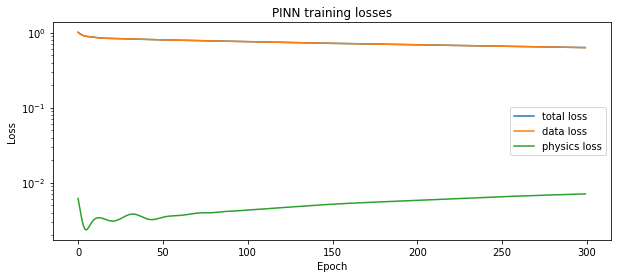

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history["total_loss"], label="total loss")
plt.plot(history["data_loss"], label="data loss")
plt.plot(history["physics_loss"], label="physics loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("PINN training losses")
plt.show()

## 7. Results

### Predict dT/dt on test set

In [17]:
# Predict scaled dT/dt on test set
y_pred_test_scaled = pinn_model(X_test_tf, training=False)

# Convert prediction and actual values back to °C/hour
y_pred_test = inverse_scale_y(y_pred_test_scaled).numpy()
y_true_test = inverse_scale_y(y_test_tf).numpy()

print("Predicted dTdt shape:", y_pred_test.shape)
print("True dTdt shape:", y_true_test.shape)

Predicted dTdt shape: (304, 2)
True dTdt shape: (304, 2)


### Local Dynamics Prediction

The PINN is first evaluated on one-step prediction of the thermal dynamics.

This corresponds to the task directly learned during training and provides insight into how accurately the model captures local temperature evolution.

### Evaluate one-step dT/dt prediction

In [18]:
metrics_one_step_dTdt = dict()

for i, target in enumerate(pinn_targets):
    room = target.split("_")[1]
    metrics_one_step_dTdt[room] = dict()
    mae_one_step_dTdt = mean_absolute_error(y_true_test[:, i], y_pred_test[:, i])
    rmse_one_step_dTdt = np.sqrt(mean_squared_error(y_true_test[:, i], y_pred_test[:, i]))
    metrics_one_step_dTdt[room]["MAE"] = mae_one_step_dTdt
    metrics_one_step_dTdt[room]["RMSE"] = rmse_one_step_dTdt

    print(
        f"PINN one-step {target}: "
        f"MAE={mae_one_step_dTdt:.4f} °C/h | RMSE={rmse_one_step_dTdt:.4f} °C/h"
    )

PINN one-step dTdt_salon: MAE=0.0912 °C/h | RMSE=0.1228 °C/h
PINN one-step dTdt_kids: MAE=0.0833 °C/h | RMSE=0.1156 °C/h


### Plot predicted vs actual dT/dt

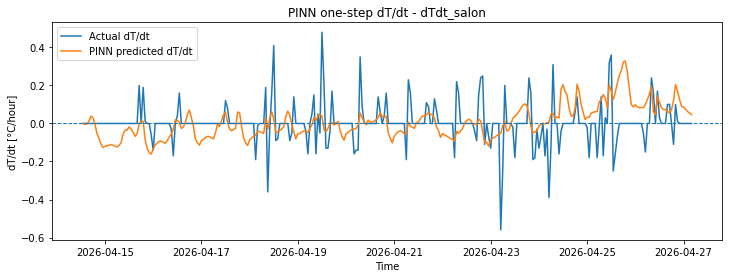

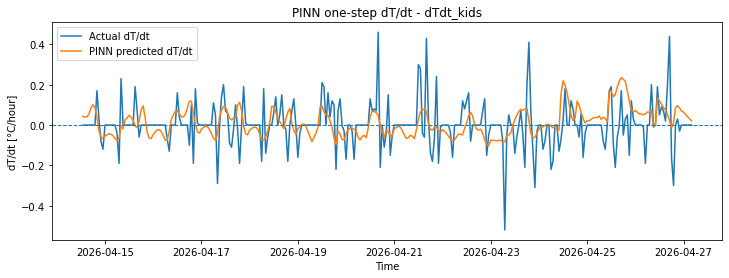

In [19]:
test_times = test_df.index

for i, target in enumerate(pinn_targets):
    plt.figure(figsize=(12, 4))
    plt.plot(test_times, y_true_test[:, i], label="Actual dT/dt")
    plt.plot(test_times, y_pred_test[:, i], label="PINN predicted dT/dt")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"PINN one-step dT/dt - {target}")
    plt.xlabel("Time")
    plt.ylabel("dT/dt [°C/hour]")
    plt.legend()
    plt.show()

### One-Step Temperature Reconstruction

The predicted temperature derivatives are integrated to reconstruct indoor temperature trajectories.

This allows evaluation of the practical temperature prediction accuracy achieved by the learned dynamics.

### One-step temperature reconstruction
T_pred(t+1) = T(t) + predicted dT/dt(t)

In [20]:
base_temps_test = test_df[["temp_salon_c", "temp_kids_c"]].values

true_next_temps = test_df[["temp_salon_c", "temp_kids_c"]].shift(-1).values[:-1]
pred_next_temps = base_temps_test[:-1] + y_pred_test[:-1]

one_step_times = test_df.index[1:]

metrics_one_step_temp = dict()

for i, target in enumerate(["temp_salon_c", "temp_kids_c"]):
    mae_one_step_temp = mean_absolute_error(true_next_temps[:, i], pred_next_temps[:, i])
    rmse_one_step_temp = np.sqrt(mean_squared_error(true_next_temps[:, i], pred_next_temps[:, i]))
    room = target.split("_")[1]
    metrics_one_step_temp[room] = dict()
    metrics_one_step_temp[room]["MAE"] = mae_one_step_temp
    metrics_one_step_temp[room]["RMSE"] = rmse_one_step_temp

    print(
        f"PINN one-step temperature {target}: "
        f"MAE={mae_one_step_temp:.3f} °C | RMSE={rmse_one_step_temp:.3f} °C"
    )

PINN one-step temperature temp_salon_c: MAE=0.091 °C | RMSE=0.123 °C
PINN one-step temperature temp_kids_c: MAE=0.084 °C | RMSE=0.116 °C


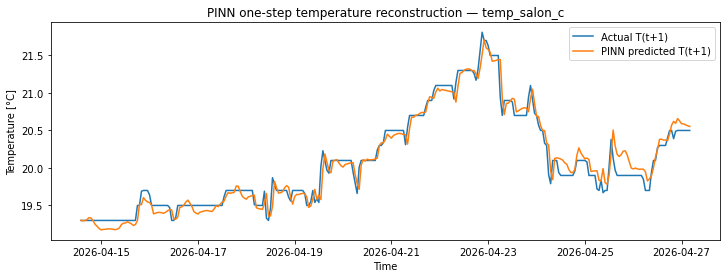

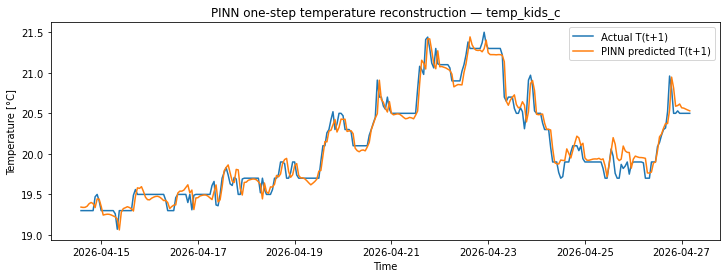

In [21]:
for i, target in enumerate(["temp_salon_c", "temp_kids_c"]):
    plt.figure(figsize=(12, 4))
    plt.plot(one_step_times, true_next_temps[:, i], label="Actual T(t+1)")
    plt.plot(one_step_times, pred_next_temps[:, i], label="PINN predicted T(t+1)")
    plt.title(f"PINN one-step temperature reconstruction — {target}")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.show()

## 8. Multi-Step Rollout Forecasting

While one-step predictions evaluate local dynamics, practical forecasting applications require predictions over longer horizons.

To assess long-term behavior, the learned dynamics are recursively integrated over a 12-hour horizon.

In [22]:
def pinn_rollout(
    model,
    start_row,
    exog_df,
    steps,
    x_scaler,
    y_scaler,
    pinn_features,
):
    """
    Roll out the learned thermal model  for a number of hourly steps.

    start_row: row containing initial indoor tempretures.
    exog_df: dataframe containing future exogeneous variables for each step
    steps: number of rollout steps
    """

    temps = []

    current_salon = float(start_row["temp_salon_c"])
    current_kids = float(start_row["temp_kids_c"])
    
    for step in range(steps):
        row = exog_df.iloc[step].copy()

        # Update indoor states with simulated values
        row["temp_salon_c"] = current_salon
        row["temp_kids_c"] = current_kids

        # Recompute drivers based on simulated indoor temps
        row["driver_salon"] = row["temp_out_mean_c"] - row["temp_salon_c"]
        row["driver_kids"] = row["temp_out_mean_c"] - row["temp_kids_c"]

        X_row_raw = row[pinn_features].values.reshape(1, -1)
        X_row_scaled = x_scaler.transform(X_row_raw)

        X_row_tf = tf.constant(X_row_scaled, dtype=tf.float32)

        pred_scaled = model(X_row_tf, training=False)
        pred_dTdt = inverse_scale_y(pred_scaled).numpy()[0]

        current_salon = current_salon + pred_dTdt[0]
        current_kids = current_kids + pred_dTdt[1]
        
        temps.append([current_salon, current_kids])

    return np.array(temps)

### Prepare Rollout dataframe

In [23]:
rollout_df = pinn_df.copy()

# Make sure all required features exist
rollout_df = rollout_df.dropna().copy()

rollout_steps = 12
start_idx = 0 # first point in test period

start_time = test_df.index[start_idx]
start_row = test_df.iloc[start_idx].copy()

future_exog = test_df.iloc[start_idx:start_idx + rollout_steps].copy()

rollout_pred = pinn_rollout(
    model=pinn_model,
    start_row=start_row,
    exog_df=future_exog,
    steps=rollout_steps,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    pinn_features=pinn_features
)

rollout_times = test_df.index[start_idx + 1: start_idx + rollout_steps + 1]

actual_rollout = test_df.loc[
    rollout_times,
    ["temp_salon_c", "temp_kids_c"]
].values

print("Rollout pred:", rollout_pred.shape)
print("Actual_rollour:", actual_rollout.shape)

Rollout pred: (12, 2)
Actual_rollour: (12, 2)


### Plot single 12h rollout

The following example illustrates a single recursive 12-hour forecast produced by the PINN.

Small local prediction errors can accumulate over time, making rollout evaluation significantly more challenging than one-step prediction.

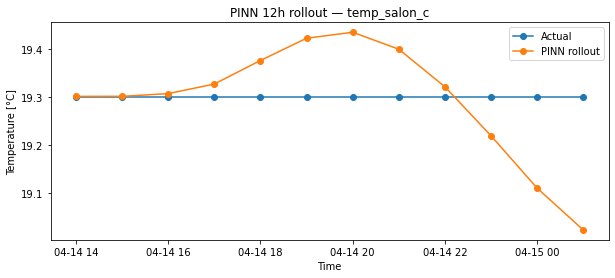

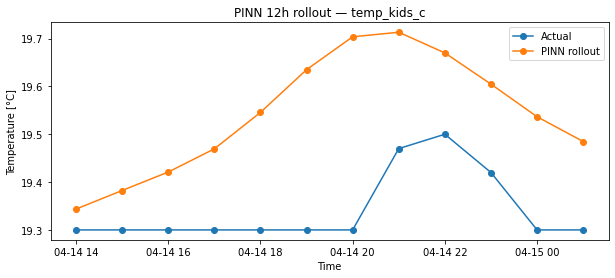

In [24]:
for i, target in enumerate(["temp_salon_c", "temp_kids_c"]):
    plt.figure(figsize=(10, 4))
    plt.plot(rollout_times, actual_rollout[:, i], marker="o", label="Actual")
    plt.plot(rollout_times, rollout_pred[:, i], marker="o", label="PINN rollout")
    plt.title(f"PINN 12h rollout — {target}")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.show()

### Rollout Evaluation

To obtain a robust estimate of forecasting performance, the recursive rollout procedure is repeated across the entire test set.

The resulting metrics quantify the practical forecasting accuracy achievable over a 12-hour horizon.

### Evaluate rolling 12h rollouts across test set

In [25]:
rollout_horizon = 12

all_preds = []
all_actuals = []
all_times = []

max_start = len(test_df) - rollout_horizon - 1

for start_idx in range(max_start):
    start_row = test_df.iloc[start_idx].copy()
    future_exog = test_df.iloc[start_idx:start_idx + rollout_horizon].copy()

    pred = pinn_rollout(
        model=pinn_model,
        start_row=start_row,
        exog_df=future_exog,
        steps=rollout_horizon,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        pinn_features=pinn_features,
    )

    target_times = test_df.index[start_idx + 1:start_idx + rollout_horizon + 1]

    actual = test_df.loc[
        target_times,
        ["temp_salon_c", "temp_kids_c"]
    ].values

    all_preds.append(pred[-1])       # only final +12h prediction
    all_actuals.append(actual[-1])   # actual +12h
    all_times.append(target_times[-1])

all_preds = np.array(all_preds)
all_actuals = np.array(all_actuals)
all_times = pd.DatetimeIndex(all_times)

metrics_12h = dict()

for i, target in enumerate(["temp_salon_c", "temp_kids_c"]):
    room = target.split("_")[1]
    metrics_12h[room] = dict()
    mae_12h = mean_absolute_error(all_actuals[:, i], all_preds[:, i])
    rmse_12h = np.sqrt(mean_squared_error(all_actuals[:, i], all_preds[:, i]))
    metrics_12h[room]["MAE"] = mae_12h
    metrics_12h[room]["RMSE"] = rmse_12h

    print(
        f"PINN rollout +{rollout_horizon}h {target}: "
        f"MAE={mae_12h:.3f} °C | RMSE={rmse_12h:.3f} °C"
    )

PINN rollout +12h temp_salon_c: MAE=0.415 °C | RMSE=0.505 °C
PINN rollout +12h temp_kids_c: MAE=0.309 °C | RMSE=0.399 °C


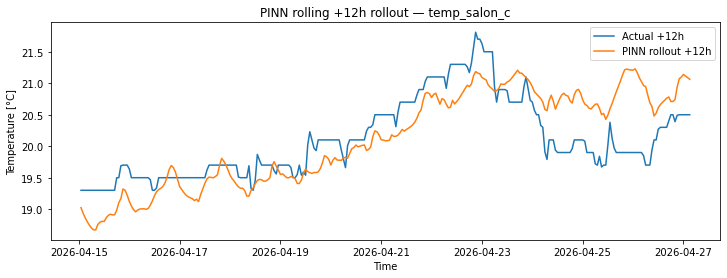

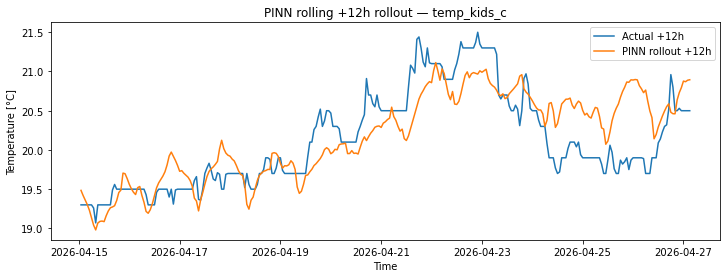

In [26]:
for i, target in enumerate(["temp_salon_c", "temp_kids_c"]):
    plt.figure(figsize=(12, 4))
    plt.plot(all_times, all_actuals[:, i], label="Actual +12h")
    plt.plot(all_times, all_preds[:, i], label="PINN rollout +12h")
    plt.title(f"PINN rolling +12h rollout — {target}")
    plt.xlabel("Time")
    plt.ylabel("Temperature [°C]")
    plt.legend()
    plt.show()

## 9. Comparison with Previous Forecasting Approaches

To place the PINN results in context, we compare them with the models evaluated in the previous notebook.

It is important to note that the PINN operates differently from the direct forecasting models.

While Random Forest and LSTM-based approaches directly predict future temperatures, the PINN learns local thermal dynamics and generates forecasts through recursive integration.

Therefore, the comparison should be interpreted as a comparison of forecasting strategies rather than a strict one-to-one benchmark.

In [27]:
comparison_df = pd.DataFrame([
    {"Model": "Persistence", "Target": "T(t+12h)", "Evaluation": "Direct +12h", "MAE": 0.263549, "RMSE": 0.367761},
    {"Model": "Random Forest", "Target": "T(t+12h)", "Evaluation": "Direct +12h", "MAE": 0.275905, "RMSE": 0.367761},
    {"Model": "LSTM", "Target": "T(t+12h)", "Evaluation": "Direct +12h", "MAE": 0.396309, "RMSE": 0.507912},
    {"Model": "Physics-inspired LSTM", "Target": "ΔT(t+12h)", "Evaluation": "Direct +12h", "MAE": 0.238481, "RMSE": 0.318237},
    {"Model": "Physics-inspired LSTM Residuals", "Target": "ΔT(t+12h)", "Evaluation": "Direct +12h", "MAE": 0.215611, "RMSE": 0.287918},

    {"Model": "PINN Rollout - Living Room", "Target": "T(t+12h)", "Evaluation": "12h recursive rollout", "MAE": metrics_12h["salon"]["MAE"], "RMSE": metrics_12h["salon"]["RMSE"]},
    {"Model": "PINN Rollout - Bedroom", "Target": "T(t+12h)", "Evaluation": "12h recursive rollout", "MAE": metrics_12h["kids"]["MAE"], "RMSE": metrics_12h["kids"]["RMSE"]},
])
comparison_df

,Model,Target,Evaluation,MAE,RMSE
0,Persistence,T(t+12h),Direct +12h,0.263549,0.367761
1,Random Forest,T(t+12h),Direct +12h,0.275905,0.367761
2,LSTM,T(t+12h),Direct +12h,0.396309,0.507912
3,Physics-inspired LSTM,ΔT(t+12h),Direct +12h,0.238481,0.318237
4,Physics-inspired LSTM Residuals,ΔT(t+12h),Direct +12h,0.215611,0.287918
5,PINN Rollout - Living Room,T(t+12h),12h recursive rollout,0.415253,0.505242
6,PINN Rollout - Bedroom,T(t+12h),12h recursive rollout,0.309138,0.398538


In [28]:
pinn_local_df = pd.DataFrame([
    {"Room": "Living Room", "Task": "One-step dT/dt", "MAE": metrics_one_step_dTdt["salon"]["MAE"], "RMSE": metrics_one_step_dTdt["salon"]["RMSE"]},
    {"Room": "Bedroom", "Task": "One-step dT/dt", "MAE": metrics_one_step_dTdt["kids"]["MAE"], "RMSE": metrics_one_step_dTdt["kids"]["RMSE"]},
    {"Room": "Living Room", "Task": "One-step temperature reconstruction", "MAE": metrics_one_step_temp["salon"]["MAE"], "RMSE": metrics_one_step_temp["salon"]["RMSE"]},
    {"Room": "Bedroom", "Task": "One-step temperature reconstruction", "MAE": metrics_one_step_temp["kids"]["MAE"], "RMSE": metrics_one_step_temp["kids"]["RMSE"]},
])
pinn_local_df

,Room,Task,MAE,RMSE
0,Living Room,One-step dT/dt,0.091221,0.122781
1,Bedroom,One-step dT/dt,0.083320,0.115574
2,Living Room,One-step temperature reconstruction,0.091369,0.122955
3,Bedroom,One-step temperature reconstruction,0.083527,0.115759


## 10. Key Takeaways

The PINN successfully learns local thermal dynamics with high one-step accuracy.

However, recursive multi-step forecasting remains challenging, as small local errors accumulate during rollout.

Compared to purely data-driven models, the PINN offers several advantages:

- Physically meaningful predictions
- Interpretable thermal coefficients
- Improved consistency with known thermal behavior

The results highlight an important lesson:

Incorporating physics into the learning process does not automatically guarantee the lowest forecasting error.

Instead, it provides a trade-off between accuracy, interpretability and physical consistency.

This suggests that physics-informed learning can complement traditional machine learning approaches rather than simply replace them.